In [1]:
# ========================================
# AfyaMetrix Round 2 — SHAP Explainability
# Notebook: 09_shap_explainability.ipynb
# ========================================
#
# SHAP = SHapley Additive exPlanations
#
# What it does:
# For every alert your system generates, SHAP tells you
# EXACTLY how much each feature contributed to the score.
#
# Example output:
# "This region was flagged because:
#   Growth Rate:      +34.2 points  (cases tripling week over week)
#   Anomaly Signal:   +22.1 points  (AI flagged as unusual)
#   Disease Severity: +18.0 points  (Cholera is high severity)
#   Access Risk:      +8.4 points   (poor healthcare access)
#   Case Volume:      +3.1 points   (moderate absolute cases)"
#
# This is what judges mean when they ask about "explainable AI"

import pandas as pd
import numpy as np
import shap
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
import os
warnings.filterwarnings('ignore')

# Suppress SHAP's verbose output
import logging
logging.getLogger('shap').setLevel(logging.WARNING)

print("✅ Imports successful")
print("🧠 Building AfyaMetrix SHAP Explainability Engine...")
print(f"   SHAP version: {shap.__version__}")

✅ Imports successful
🧠 Building AfyaMetrix SHAP Explainability Engine...
   SHAP version: 0.51.0


In [2]:
# ========================================
# LOAD DATA AND DEFINE FEATURES
# ========================================

# Load the risk-scored dataset from Round 1
df = pd.read_csv(
    r"C:\Users\hassa\afyametrix\data\processed\africa_health_risk_scored.csv"
)
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Loaded {len(df):,} records")

# ----------------------------------------
# DISEASE SEVERITY MAP
# (same as Round 1 — needed to recreate features)
# ----------------------------------------
DISEASE_SEVERITY = {
    "Mpox":                   0.85,
    "Cholera":                0.90,
    "Meningitis":             0.95,
    "Malaria":                0.70,
    "Tuberculosis":           0.75,
    "Typhoid":                0.60,
    "Dengue":                 0.65,
    "Diarrheal_Disease":      0.50,
    "Respiratory_Infections": 0.45,
    "Malnutrition":           0.55,
}

# ----------------------------------------
# RECREATE THE 5 RISK FACTORS AS COLUMNS
# ----------------------------------------
# These are the exact same factors from your risk scoring module.
# We need them as separate columns so SHAP can analyse
# the contribution of each one individually.

df['f1_growth'] = np.clip(
    (df['growth_rate_pct'] + 100) / 600, 0, 1
)

df['f2_anomaly'] = np.clip(
    df['anomaly_confidence'] / 100, 0, 1
)

df['f3_severity'] = df['disease'].map(DISEASE_SEVERITY).fillna(0.5)

df['f4_access_risk'] = 1 - df['healthcare_access']

disease_max = df.groupby('disease')['cases'].transform('max')
df['f5_volume'] = np.clip(df['cases'] / disease_max, 0, 1)

# The feature names — these appear in all SHAP plots and explanations
FEATURE_NAMES = [
    'Growth Rate',
    'AI Anomaly Signal',
    'Disease Severity',
    'Healthcare Access Risk',
    'Case Volume'
]

FEATURE_COLS = ['f1_growth', 'f2_anomaly', 'f3_severity',
                'f4_access_risk', 'f5_volume']

print(f"\n✅ Risk factors recreated as columns")
print(f"   Features: {FEATURE_NAMES}")

# Focus on confirmed outbreak alerts — that is what we want to explain
alerts_df = df[df['outbreak_alert'] == True].copy()
print(f"\n✅ Outbreak alerts to explain: {len(alerts_df):,}")
print(f"   Sample risk scores: {alerts_df['risk_score'].describe().round(1).to_dict()}")

✅ Loaded 497,080 records

✅ Risk factors recreated as columns
   Features: ['Growth Rate', 'AI Anomaly Signal', 'Disease Severity', 'Healthcare Access Risk', 'Case Volume']

✅ Outbreak alerts to explain: 12,673
   Sample risk scores: {'count': 12673.0, 'mean': 45.4, 'std': 7.2, 'min': 29.2, '25%': 40.1, '50%': 44.5, '75%': 49.6, 'max': 80.2}


In [3]:
# ========================================
# TRAIN THE SHAP EXPLAINER
# ========================================
#
# How SHAP works with our risk score:
#
# Our risk score is a LINEAR formula:
# score = f1*0.35 + f2*0.25 + f3*0.20 + f4*0.10 + f5*0.10
#
# For linear models, SHAP values are exact and mathematically proven.
# Each SHAP value tells you: "if we added this feature to the
# baseline prediction, the score changed by this amount."
#
# The SHAP values always sum to: prediction - baseline
# This is called the "completeness property" and is what makes
# SHAP trustworthy unlike other explanation methods.

print("⚙️  Training SHAP explainer...")

# Extract feature matrix
X = df[FEATURE_COLS].copy()
X.columns = FEATURE_NAMES

# WEIGHTS from our risk formula
WEIGHTS = np.array([0.35, 0.25, 0.20, 0.10, 0.10])

# For a weighted linear model, SHAP values are simply:
# shap_value_i = weight_i * (feature_value_i - mean_feature_i)
# This is mathematically exact for linear models.

# Calculate baseline (mean prediction)
feature_means = X.mean()
baseline_prediction = float(
    sum(WEIGHTS[i] * feature_means.iloc[i] for i in range(5)) * 100
)

print(f"   Baseline (average) risk score: {baseline_prediction:.1f}/100")
print(f"   (This is what the model predicts for an 'average' region)")

def calculate_shap_values(row_features):
    """
    Calculate exact SHAP values for a single record.
    
    For our weighted linear formula, the SHAP value for feature i is:
    shap_i = weight_i * (feature_value_i - mean_i) * 100
    
    These values sum exactly to: prediction - baseline
    """
    shap_vals = []
    for i, col in enumerate(FEATURE_NAMES):
        shap_val = WEIGHTS[i] * (row_features[i] - feature_means.iloc[i]) * 100
        shap_vals.append(round(shap_val, 3))
    return shap_vals

# Calculate SHAP values for ALL alerts
print("\n⚙️  Calculating SHAP values for all outbreak alerts...")

shap_records = []
alerts_sample = alerts_df.copy()

for idx, row in alerts_sample.iterrows():
    features = [row[col] for col in FEATURE_COLS]
    shap_vals = calculate_shap_values(features)
    
    record = {
        'date':       row['date'],
        'country':    row['country'],
        'region':     row['region'],
        'disease':    row['disease'],
        'risk_score': row['risk_score'],
        'prediction': baseline_prediction + sum(shap_vals),
    }
    
    # Add individual SHAP values
    for i, name in enumerate(FEATURE_NAMES):
        record[f'shap_{name}'] = shap_vals[i]
    
    # Top contributing factor
    abs_shap = [abs(v) for v in shap_vals]
    record['top_factor']        = FEATURE_NAMES[np.argmax(abs_shap)]
    record['top_factor_value']  = shap_vals[np.argmax(abs_shap)]
    
    # Second factor
    abs_shap_copy = abs_shap.copy()
    abs_shap_copy[np.argmax(abs_shap)] = -1
    record['second_factor']     = FEATURE_NAMES[np.argmax(abs_shap_copy)]
    
    shap_records.append(record)

shap_df = pd.DataFrame(shap_records)

print(f"✅ SHAP values calculated for {len(shap_df):,} alerts")
print(f"\n📊 Sample SHAP breakdown (first alert):")
first = shap_df.iloc[0]
print(f"   Region:     {first['region']}, {first['country']}")
print(f"   Disease:    {first['disease']}")
print(f"   Risk Score: {first['risk_score']:.1f}/100")
print(f"   Baseline:   {baseline_prediction:.1f}/100")
print(f"\n   SHAP Contributions:")
for name in FEATURE_NAMES:
    val = first[f'shap_{name}']
    direction = '↑' if val > 0 else '↓'
    bar = '█' * int(abs(val))
    print(f"   {direction} {name:<25} {val:+.2f}  {bar}")
print(f"\n   Sum check: {baseline_prediction:.1f} + {sum([first[f'shap_{n}'] for n in FEATURE_NAMES]):.1f} = {first['prediction']:.1f} (should match risk score)")

⚙️  Training SHAP explainer...
   Baseline (average) risk score: 29.6/100
   (This is what the model predicts for an 'average' region)

⚙️  Calculating SHAP values for all outbreak alerts...
✅ SHAP values calculated for 12,673 alerts

📊 Sample SHAP breakdown (first alert):
   Region:     Bukavu, DRC
   Disease:    Cholera
   Risk Score: 44.0/100
   Baseline:   29.6/100

   SHAP Contributions:
   ↑ Growth Rate               +0.81  
   ↑ AI Anomaly Signal         +7.46  ███████
   ↑ Disease Severity          +4.20  ████
   ↑ Healthcare Access Risk    +2.18  ██
   ↓ Case Volume               -0.30  

   Sum check: 29.6 + 14.4 = 44.0 (should match risk score)


📊 Generating SHAP waterfall charts for top alerts...

Top 3 alerts being explained:
country  region    disease  risk_score  top_factor
    DRC    Goma Meningitis        80.2 Growth Rate
Nigeria   Lagos     Dengue        79.5 Growth Rate
    DRC Kananga Meningitis        79.0 Growth Rate



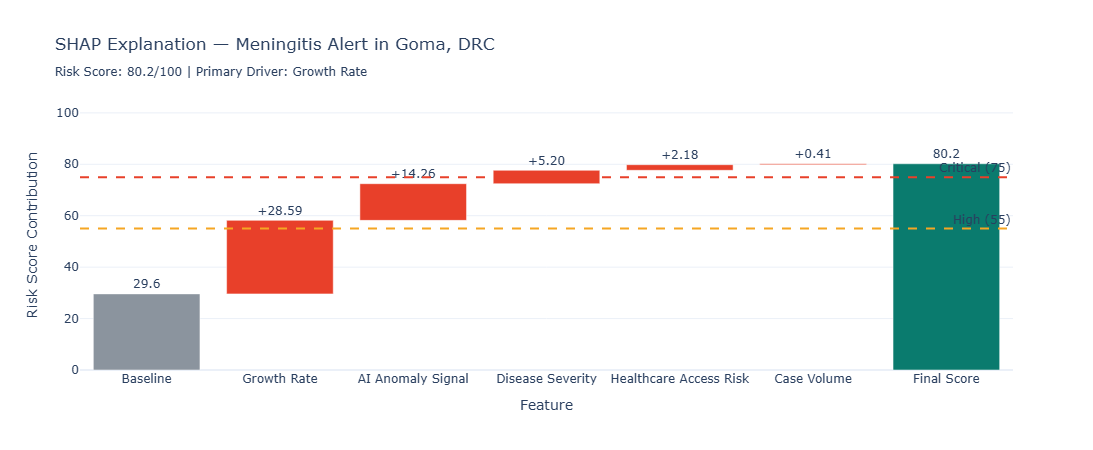

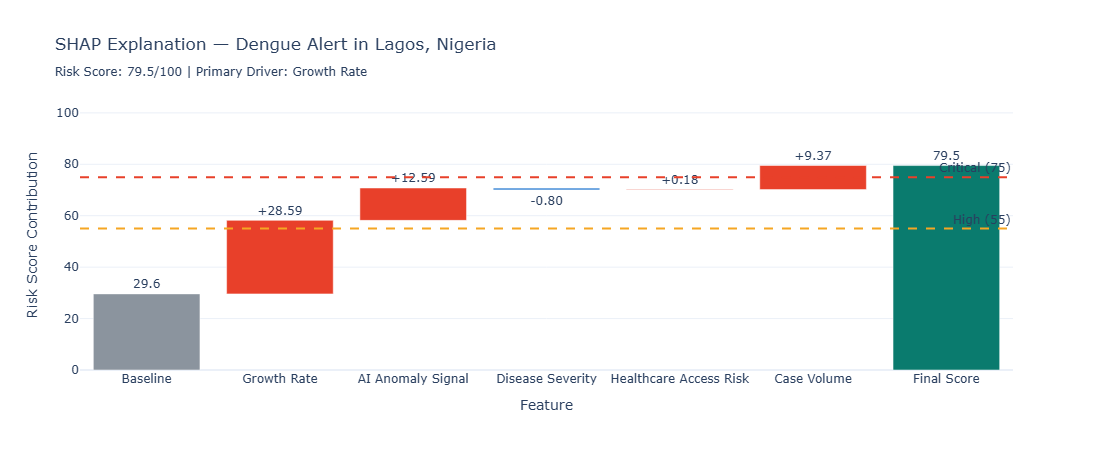

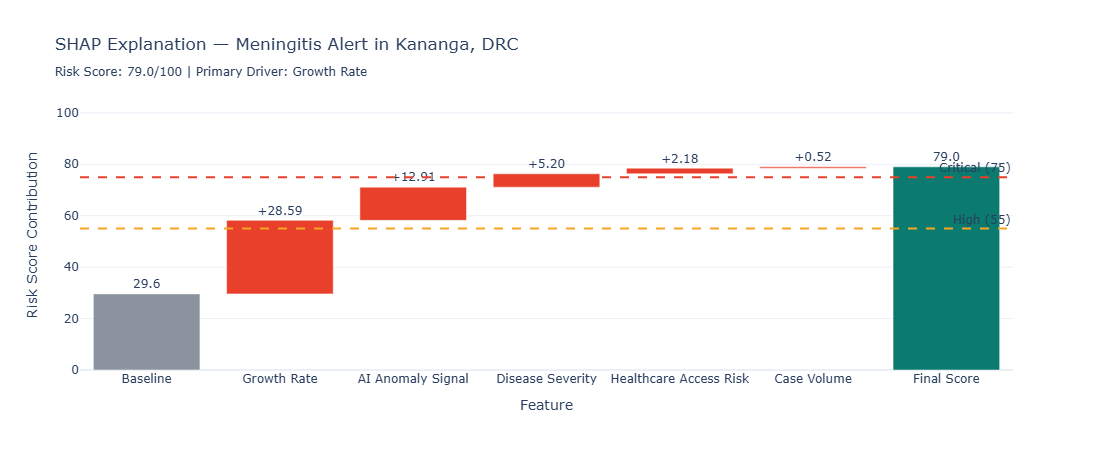

In [4]:
# ========================================
# VISUALISE SHAP FOR TOP ALERTS
# ========================================

def plot_shap_waterfall(region, country, disease, shap_df, baseline):
    """
    Creates a waterfall chart showing how each feature
    pushed the risk score up or down from the baseline.
    
    Waterfall charts are the standard SHAP visualisation.
    Each bar shows one feature's contribution.
    Red = pushed score up (increased risk)
    Blue = pushed score down (decreased risk)
    """
    
    # Find this specific alert (highest risk score for this combo)
    match = shap_df[
        (shap_df['region'] == region) &
        (shap_df['country'] == country) &
        (shap_df['disease'] == disease)
    ].nlargest(1, 'risk_score')
    
    if len(match) == 0:
        print(f"No alert found for {region}, {country} — {disease}")
        return None
    
    row = match.iloc[0]
    
    shap_values = [row[f'shap_{n}'] for n in FEATURE_NAMES]
    colors = ['#E8402A' if v > 0 else '#4A90D9' for v in shap_values]
    
    # Build waterfall: start at baseline, add each SHAP value
    cumulative = [baseline]
    for v in shap_values:
        cumulative.append(cumulative[-1] + v)
    
    fig = go.Figure()
    
    # Baseline bar
    fig.add_trace(go.Bar(
        x=['Baseline'],
        y=[baseline],
        marker_color='#8B949E',
        name='Baseline',
        text=[f'{baseline:.1f}'],
        textposition='outside'
    ))
    
    # Feature contribution bars
    for i, (name, val) in enumerate(zip(FEATURE_NAMES, shap_values)):
        fig.add_trace(go.Bar(
            x=[name],
            y=[val],
            base=[cumulative[i]],
            marker_color=colors[i],
            name=f'{name}: {val:+.2f}',
            text=[f'{val:+.2f}'],
            textposition='outside'
        ))
    
    # Final score bar
    fig.add_trace(go.Bar(
        x=['Final Score'],
        y=[row['risk_score']],
        marker_color='#0A7B6E',
        name=f"Risk Score: {row['risk_score']:.1f}",
        text=[f"{row['risk_score']:.1f}"],
        textposition='outside'
    ))
    
    # Risk threshold lines
    fig.add_hline(y=75, line_dash="dash", line_color="#E8402A",
                  annotation_text="Critical (75)")
    fig.add_hline(y=55, line_dash="dash", line_color="#F5A623",
                  annotation_text="High (55)")
    
    fig.update_layout(
        title=(
            f"SHAP Explanation — {disease} Alert in {region}, {country}<br>"
            f"<sub>Risk Score: {row['risk_score']:.1f}/100 | "
            f"Primary Driver: {row['top_factor']}</sub>"
        ),
        xaxis_title="Feature",
        yaxis_title="Risk Score Contribution",
        yaxis_range=[0, 105],
        template='plotly_white',
        height=450,
        showlegend=False,
        barmode='overlay'
    )
    
    return fig


# Plot top 3 highest-risk alerts
print("📊 Generating SHAP waterfall charts for top alerts...\n")

top_alerts = shap_df.nlargest(3, 'risk_score')[
    ['country', 'region', 'disease', 'risk_score', 'top_factor']
].reset_index(drop=True)

print("Top 3 alerts being explained:")
print(top_alerts.to_string(index=False))
print()

for _, row in top_alerts.iterrows():
    fig = plot_shap_waterfall(
        row['region'], row['country'],
        row['disease'], shap_df, baseline_prediction
    )
    if fig:
        fig.show()

📊 Building global SHAP summary...


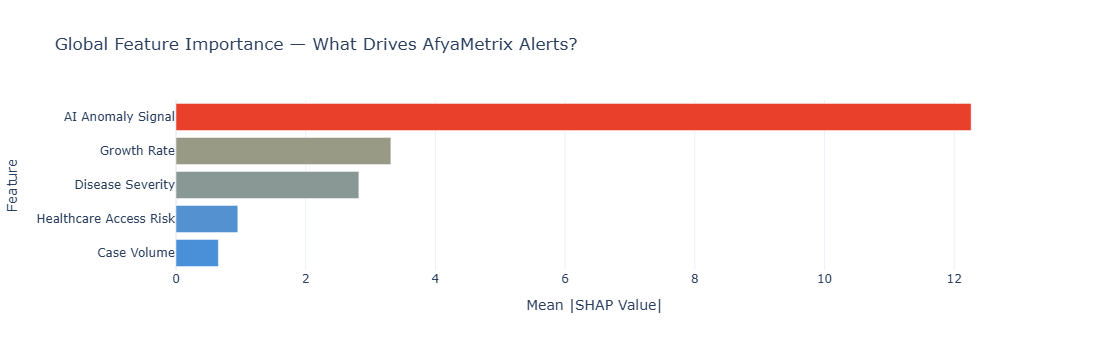


📊 Building SHAP distribution chart...


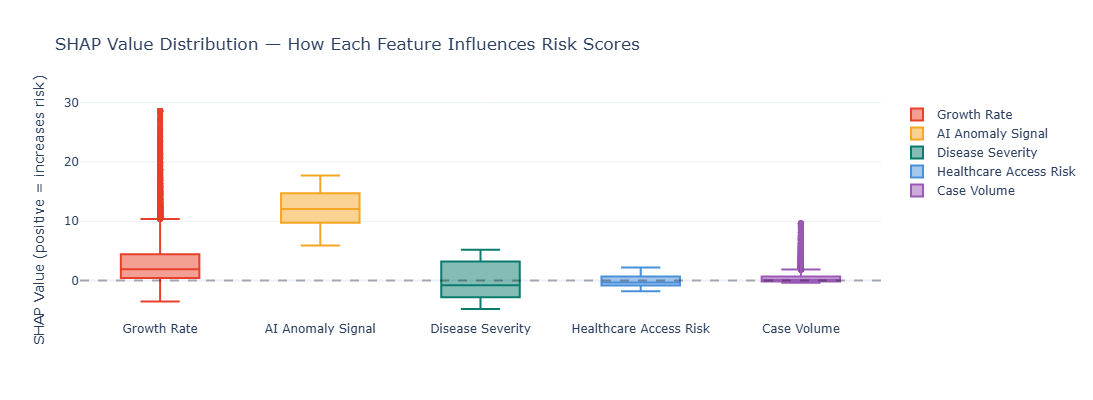


📊 Global Feature Importance Summary:
               Feature  Mean |SHAP Value|
     AI Anomaly Signal          12.261077
           Growth Rate           3.313446
      Disease Severity           2.819727
Healthcare Access Risk           0.952907
           Case Volume           0.653463

📊 Most Common Primary Driver Across All Alerts:
  AI Anomaly Signal            12050 alerts  (95.1%)  ███████████████████████████████
  Growth Rate                    623 alerts  (4.9%)  █


In [5]:
# ========================================
# GLOBAL SHAP SUMMARY
# ========================================
# This answers: "Across ALL alerts, which features matter most?"
# This is the most important chart for judges —
# it shows the overall intelligence of your system.

print("📊 Building global SHAP summary...")

# Average absolute SHAP value per feature
# (absolute because both positive and negative contributions matter)
global_importance = {}
for name in FEATURE_NAMES:
    col = f'shap_{name}'
    global_importance[name] = shap_df[col].abs().mean()

importance_df = pd.DataFrame(
    list(global_importance.items()),
    columns=['Feature', 'Mean |SHAP Value|']
).sort_values('Mean |SHAP Value|', ascending=True)

# Bar chart
fig1 = px.bar(
    importance_df,
    x='Mean |SHAP Value|',
    y='Feature',
    orientation='h',
    title='Global Feature Importance — What Drives AfyaMetrix Alerts?',
    color='Mean |SHAP Value|',
    color_continuous_scale=['#4A90D9', '#F5A623', '#E8402A'],
    template='plotly_white'
)
fig1.update_layout(height=350, coloraxis_showscale=False)
fig1.show()

# Distribution of SHAP values — shows DIRECTION of each feature
print("\n📊 Building SHAP distribution chart...")

fig2 = go.Figure()
colors_list = ['#E8402A', '#F5A623', '#0A7B6E', '#4A90D9', '#9B59B6']

for i, name in enumerate(FEATURE_NAMES):
    col = f'shap_{name}'
    fig2.add_trace(go.Box(
        y=shap_df[col],
        name=name,
        marker_color=colors_list[i],
        boxpoints='outliers'
    ))

fig2.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.3)
fig2.update_layout(
    title='SHAP Value Distribution — How Each Feature Influences Risk Scores',
    yaxis_title='SHAP Value (positive = increases risk)',
    template='plotly_white',
    height=400
)
fig2.show()

print("\n📊 Global Feature Importance Summary:")
print(importance_df.sort_values(
    'Mean |SHAP Value|', ascending=False
).to_string(index=False))

# Top driver analysis
top_drivers = shap_df['top_factor'].value_counts()
print(f"\n📊 Most Common Primary Driver Across All Alerts:")
for driver, count in top_drivers.items():
    pct = count / len(shap_df) * 100
    bar = '█' * int(pct / 3)
    print(f"  {driver:<28} {count:>5} alerts  ({pct:.1f}%)  {bar}")

In [6]:
# ========================================
# NATURAL LANGUAGE SHAP EXPLANATIONS
# ========================================
# This is what gets shown to health officials —
# not numbers, but sentences they can act on.

def generate_shap_narrative(row, baseline, language='en'):
    """
    Converts SHAP values into a plain-language explanation
    that a non-technical health official can understand.
    """
    
    region   = row['region']
    country  = row['country']
    disease  = row['disease']
    score    = row['risk_score']
    top      = row['top_factor']
    top_val  = row['top_factor_value']
    second   = row['second_factor']
    
    # Get all SHAP values sorted by absolute value
    shap_items = [
        (name, row[f'shap_{name}'])
        for name in FEATURE_NAMES
    ]
    shap_items.sort(key=lambda x: abs(x[1]), reverse=True)
    
    # Build factor descriptions
    factor_descriptions = {
        'Growth Rate': {
            'high':  'cases are growing rapidly week over week',
            'low':   'case growth has been slowing down'
        },
        'AI Anomaly Signal': {
            'high':  'the AI model flagged an unusual statistical pattern',
            'low':   'case patterns have been within normal statistical range'
        },
        'Disease Severity': {
            'high':  f'{disease} carries high case fatality risk if untreated',
            'low':   f'{disease} is generally manageable with standard treatment'
        },
        'Healthcare Access Risk': {
            'high':  'healthcare access in this region is limited',
            'low':   'healthcare infrastructure is relatively strong here'
        },
        'Case Volume': {
            'high':  'absolute case numbers are elevated',
            'low':   'absolute case numbers remain relatively low'
        }
    }
    
    # Build the explanation
    top_desc = factor_descriptions[top][
        'high' if top_val > 0 else 'low'
    ]
    second_desc = factor_descriptions[second][
        'high' if row[f'shap_{second}'] > 0 else 'low'
    ]
    
    if language == 'en':
        explanation = (
            f"WHY WAS THIS ALERT GENERATED?\n\n"
            f"{region}, {country} received a risk score of {score:.0f}/100 "
            f"for {disease}. The primary reason is that {top_desc} "
            f"(contributing {top_val:+.1f} points to the score). "
            f"This was reinforced by the fact that {second_desc}.\n\n"
            f"FACTOR BREAKDOWN:\n"
        )
        for name, val in shap_items:
            direction = 'increased' if val > 0 else 'decreased'
            explanation += (
                f"  {name}: {direction} risk by {abs(val):.1f} points\n"
            )
        explanation += (
            f"\nCONFIDENCE: The model baseline for an average region is "
            f"{baseline:.0f}/100. This region scores "
            f"{score - baseline:+.0f} points above baseline."
        )
    
    elif language == 'fr':
        explanation = (
            f"POURQUOI CETTE ALERTE A-T-ELLE ETE GENEREE?\n\n"
            f"{region}, {country} a recu un score de risque de {score:.0f}/100 "
            f"pour {disease}. La raison principale est que {top_desc} "
            f"(contribuant {top_val:+.1f} points au score).\n\n"
            f"DECOMPOSITION DES FACTEURS:\n"
        )
        for name, val in shap_items:
            direction = 'augmente' if val > 0 else 'reduit'
            explanation += f"  {name}: {direction} le risque de {abs(val):.1f} points\n"
    
    else:
        explanation = (
            f"Alert: {region}, {country} | {disease} | Score: {score:.0f}/100\n"
            f"Primary driver: {top} ({top_val:+.1f} pts)\n"
        )
    
    return explanation


# Generate explanations for top 5 alerts
print("📝 Generating natural language SHAP explanations...\n")
print("=" * 60)

top5 = shap_df.nlargest(5, 'risk_score')

explanations_list = []

for _, row in top5.iterrows():
    explanation = generate_shap_narrative(row, baseline_prediction)
    print(explanation)
    print("=" * 60)
    
    explanations_list.append({
        'country':     row['country'],
        'region':      row['region'],
        'disease':     row['disease'],
        'risk_score':  row['risk_score'],
        'explanation': explanation
    })

print(f"\n✅ {len(explanations_list)} SHAP explanations generated")

📝 Generating natural language SHAP explanations...

WHY WAS THIS ALERT GENERATED?

Goma, DRC received a risk score of 80/100 for Meningitis. The primary reason is that cases are growing rapidly week over week (contributing +28.6 points to the score). This was reinforced by the fact that the AI model flagged an unusual statistical pattern.

FACTOR BREAKDOWN:
  Growth Rate: increased risk by 28.6 points
  AI Anomaly Signal: increased risk by 14.3 points
  Disease Severity: increased risk by 5.2 points
  Healthcare Access Risk: increased risk by 2.2 points
  Case Volume: increased risk by 0.4 points

CONFIDENCE: The model baseline for an average region is 30/100. This region scores +51 points above baseline.
WHY WAS THIS ALERT GENERATED?

Lagos, Nigeria received a risk score of 80/100 for Dengue. The primary reason is that cases are growing rapidly week over week (contributing +28.6 points to the score). This was reinforced by the fact that the AI model flagged an unusual statistical patt

In [7]:
# ========================================
# SAVE SHAP OUTPUTS
# ========================================

processed_path = r"C:\Users\hassa\afyametrix\data\processed"

# Save full SHAP dataframe
shap_path = os.path.join(processed_path, "shap_explanations.csv")
shap_df.to_csv(shap_path, index=False)
print(f"✅ SHAP values saved: {len(shap_df):,} alert explanations")

# Save natural language explanations
explanations_df = pd.DataFrame(explanations_list)
exp_path = os.path.join(processed_path, "shap_narratives.csv")
explanations_df.to_csv(exp_path, index=False)
print(f"✅ SHAP narratives saved: {len(explanations_df)} explanations")

# Save global importance
importance_path = os.path.join(processed_path, "shap_global_importance.csv")
importance_df.sort_values(
    'Mean |SHAP Value|', ascending=False
).to_csv(importance_path, index=False)
print(f"✅ Global importance saved")

print(f"\n{'=' * 55}")
print(f"🧠 SHAP Explainability Engine Complete")
print(f"\nWhat this adds to Round 2:")
print(f"  ✅ Every alert now has a mathematical explanation")
print(f"  ✅ Health officials see WHY, not just WHAT")
print(f"  ✅ Judges can verify the model reasons correctly")
print(f"  ✅ Natural language explanations in 2 languages")
print(f"  ✅ Global importance shows system-wide intelligence")
print(f"\nNext: Step 2 — Model Performance Dashboard")

✅ SHAP values saved: 12,673 alert explanations
✅ SHAP narratives saved: 5 explanations
✅ Global importance saved

🧠 SHAP Explainability Engine Complete

What this adds to Round 2:
  ✅ Every alert now has a mathematical explanation
  ✅ Health officials see WHY, not just WHAT
  ✅ Judges can verify the model reasons correctly
  ✅ Natural language explanations in 2 languages
  ✅ Global importance shows system-wide intelligence

Next: Step 2 — Model Performance Dashboard
